In [32]:
import geopandas as gpd

In [33]:
gdf = gpd.read_file("./results/measurements_with_building_features_temp.gpkg")
gdf

,particles_mean_Particles > 0.3um / 0.1L air_particleBack,particles_mean_Particles > 0.5um / 0.1L air_particleBack,particles_mean_Particles > 1.0um / 0.1L air_particleBack,particles_mean_Particles > 10.0um / 0.1L air_particleBack,particles_mean_Particles > 2.5um / 0.1L air_particleBack,particles_mean_Particles > 5.0um / 0.1L air_particleBack,ultrafine_ufp,pm25_equiv,nearest_building_height,nearest_building_distance,mean_20nn_building_height,max_20nn_building_height,street_canyon_index,sky_view_factor,building_surface_fraction,building_density,mean_building_height_in_buffer,median_building_height_in_buffer,svf_ray,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.718316,0.281684,NaN,15.000000,17.5,0.745226,POINT (570449.85 5515440.104)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.788178,0.211822,NaN,12.833333,14.0,0.850217,POINT (570449.887 5515490.104)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,29.649221,17.5,17.5,NaN,0.815179,0.184821,NaN,12.833333,14.0,0.805092,POINT (570448.265 5515539.933)
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.908927,0.091073,NaN,11.200000,10.5,0.944192,POINT (570412.023 5515567.509)
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,23.477823,10.5,10.5,NaN,0.905566,0.094434,NaN,14.000000,14.0,0.927636,POINT (570362.504 5515573.815)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5449,938.812500,284.312500,43.375000,0.000000,0.000000,0.000000,422.166667,0.000000,NaN,NaN,NaN,NaN,NaN,0.879579,0.120421,NaN,13.500000,14.0,0.966892,POINT (570356.353 5515603.568)
5450,863.029412,259.705882,36.705882,0.705882,0.705882,0.705882,386.480392,0.705882,NaN,NaN,NaN,NaN,NaN,0.855774,0.144226,NaN,12.000000,14.0,0.968201,POINT (570401.42 5515593.682)
5451,999.625000,294.208333,33.833333,0.833333,1.291667,1.291667,442.555556,1.138889,NaN,NaN,NaN,NaN,NaN,0.816448,0.183552,NaN,11.000000,10.5,0.905248,POINT (570426.529 5515561.995)
5452,1106.100000,321.600000,47.225000,1.150000,3.350000,3.350000,491.641667,2.616667,17.5,23.927644,17.5,17.5,NaN,0.815179,0.184821,NaN,12.833333,14.0,0.766666,POINT (570450.876 5515523.027)


In [3]:
gdf["ultrafine_ufp"].max()

np.float64(4035.9465811965815)

In [ ]:
gdf["mean_building_height_in_buffer"].max()

np.float64(0.9990816759188952)

In [5]:
import matplotlib.pyplot as plt

In [28]:
varname =  "mean_20nn_building_height" # "svf_ray"

In [29]:
len(gdf[varname].notna())

6660

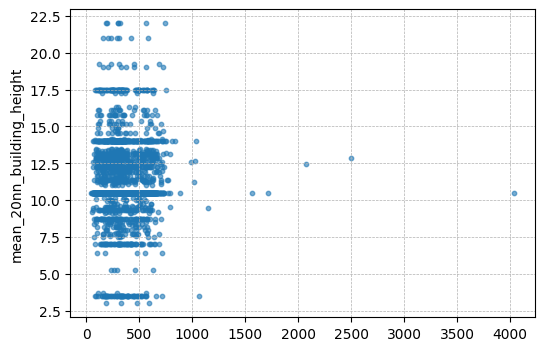

In [30]:
mask = gdf["ultrafine_ufp"].notna() & (gdf["ultrafine_ufp"] > 0) & gdf[varname].notna()
plt.figure(figsize=(6,4))
plt.scatter(gdf.loc[mask, "ultrafine_ufp"], gdf.loc[mask, varname], s=10, alpha=0.6)
#plt.xscale('log')
#plt.xlabel('ultrafine_ufp (log scale)')
plt.ylabel(f'{varname}')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

In [31]:
from scipy.stats import pearsonr, spearmanr
import numpy as np


# Extract the data
x = gdf.loc[mask, "ultrafine_ufp"].values
y = gdf.loc[mask, varname].values

# Pearson correlation (linear relationship)
pearson_r, pearson_p = pearsonr(x, y)

# Spearman correlation (monotonic relationship, more robust to outliers)
spearman_r, spearman_p = spearmanr(x, y)

print("=" * 50)
print(f"CORRELATION ANALYSIS: ultrafine_ufp vs {varname}")
print("=" * 50)
print(f"Number of valid data points: {len(x)}")
print()
print(f"Pearson Correlation:")
print(f"  Coefficient: {pearson_r:.4f}")
print(f"  P-value: {pearson_p:.4e}")
print(f"  Interpretation: {'Significant' if pearson_p < 0.05 else 'Not significant'} at α=0.05")
print()
print(f"Spearman Correlation:")
print(f"  Coefficient: {spearman_r:.4f}")
print(f"  P-value: {spearman_p:.4e}")
print(f"  Interpretation: {'Significant' if spearman_p < 0.05 else 'Not significant'} at α=0.05")
print()
print(f"Mean ultrafine_ufp: {np.mean(x):.2f}")
print(f"Mean {varname}: {np.mean(y):.4f}")
print(f"Std ultrafine_ufp: {np.std(x):.2f}")
print(f"Std {varname}: {np.std(y):.4f}")
print("=" * 50)

CORRELATION ANALYSIS: ultrafine_ufp vs mean_20nn_building_height
Number of valid data points: 2868

Pearson Correlation:
  Coefficient: 0.0175
  P-value: 3.4868e-01
  Interpretation: Not significant at α=0.05

Spearman Correlation:
  Coefficient: 0.0214
  P-value: 2.5192e-01
  Interpretation: Not significant at α=0.05

Mean ultrafine_ufp: 345.03
Mean mean_20nn_building_height: 11.1778
Std ultrafine_ufp: 184.18
Std mean_20nn_building_height: 2.5195


In [14]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

print("=" * 50)
print("PARTIAL CORRELATION ANALYSIS")
print("=" * 50)

# Get available numeric columns for control variables
numeric_cols = gdf.select_dtypes(include=['number']).columns.tolist()
available_controls = [col for col in numeric_cols if col not in ['ultrafine_ufp', varname]]

print(f"Available control variables: {available_controls[:5]}...")  # Show first 5
print()

# Example: Partial correlation controlling for one or more variables
# You can modify 'control_vars' to include different variables
control_vars = [col for col in available_controls if col in gdf.columns][:2]  # Use first 2 available

if control_vars:
    print(f"Computing partial correlation controlling for: {control_vars}")
    print()
    
    # Create dataset with all variables
    data_cols = ['ultrafine_ufp', varname] + control_vars
    data_clean = gdf[data_cols].dropna()
    
    # Step 1: Regress x (ultrafine_ufp) on control variables
    X_controls = data_clean[control_vars].values
    y_x = data_clean['ultrafine_ufp'].values
    reg_x = LinearRegression().fit(X_controls, y_x)
    residuals_x = y_x - reg_x.predict(X_controls)
    
    # Step 2: Regress y (varname) on control variables
    y_y = data_clean[varname].values
    reg_y = LinearRegression().fit(X_controls, y_y)
    residuals_y = y_y - reg_y.predict(X_controls)
    
    # Step 3: Correlate the residuals
    partial_r, partial_p = pearsonr(residuals_x, residuals_y)
    
    print(f"Partial Correlation (controlling for {control_vars}):")
    print(f"  Coefficient: {partial_r:.4f}")
    print(f"  P-value: {partial_p:.4e}")
    print(f"  Significant: {'Yes' if partial_p < 0.05 else 'No'} (α=0.05)")
    print()
    print(f"Original Pearson r: {pearson_r:.4f}")
    print(f"Difference: {abs(pearson_r - partial_r):.4f}")
    print()
else:
    print("No control variables available.")
    
print("=" * 50)
print("\nTo use different control variables, modify 'control_vars' list above.")

PARTIAL CORRELATION ANALYSIS
Available control variables: ['particles_mean_Particles > 0.3um / 0.1L air_particleBack', 'particles_mean_Particles > 0.5um / 0.1L air_particleBack', 'particles_mean_Particles > 1.0um / 0.1L air_particleBack', 'particles_mean_Particles > 10.0um / 0.1L air_particleBack', 'particles_mean_Particles > 2.5um / 0.1L air_particleBack']...

Computing partial correlation controlling for: ['particles_mean_Particles > 0.3um / 0.1L air_particleBack', 'particles_mean_Particles > 0.5um / 0.1L air_particleBack']

Partial Correlation (controlling for ['particles_mean_Particles > 0.3um / 0.1L air_particleBack', 'particles_mean_Particles > 0.5um / 0.1L air_particleBack']):
  Coefficient: -0.0223
  P-value: 1.6986e-01
  Significant: No (α=0.05)

Original Pearson r: -0.0439
Difference: 0.0216


To use different control variables, modify 'control_vars' list above.
